In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
from pathlib import Path
import pandas as pd

In [3]:
ROOT_DIR = Path("/content/drive/MyDrive/Gates Foundation/Building Dataset Validation/outputs/metrics")
OUT_DIR = "/content/drive/MyDrive/Gates Foundation/Building Dataset Validation/outputs/global_metrics"
SUMMARY_FILENAME = "vector_city_summary_all_datasets.csv"

# metrics averaged with a weighted mean (weight = n_ref_total)
WEIGHTED_MEAN_COLS = [
    "precision_city",
    "recall_city",
    "f1_city",
    "iou_mean_tp",
    "iou_median_tp",
    "iou_p25_tp",
    "iou_p75_tp",
    "boundary_f_meanpair_tp",
    "rel_area_error_mean_tp",
    "rel_area_error_median_tp",
    "signed_area_bias_tp",
]

# columns that are summed across cities
SUM_COLS = [
    "n_sub_areas",
    "n_tiles",
    "n_ref_total",
    "n_cand_total",
    "tp_total",
    "fp_total",
    "fn_total",
]


In [4]:
def load_all_cities(root: Path) -> pd.DataFrame:
    """Walk root/<CITY>/SUMMARY_FILENAME and concatenate all found files."""
    frames, missing = [], []

    city_dirs = sorted([p for p in root.iterdir() if p.is_dir()])
    if not city_dirs:
        raise FileNotFoundError(f"No sub-directories found under '{root}'.")

    for city_dir in city_dirs:
        csv_path = city_dir / SUMMARY_FILENAME
        if not csv_path.exists():
            missing.append(city_dir.name)
            continue
        df = pd.read_csv(csv_path)
        df["city"] = city_dir.name   # folder name is the authoritative city key
        frames.append(df)
        print(f"  [OK]   {city_dir.name:30s}  ({len(df)} rows)")

    if missing:
        print(f"\n  [WARN] No '{SUMMARY_FILENAME}' found for: {missing}")

    if not frames:
        raise RuntimeError("No CSV files were loaded. Nothing to aggregate.")

    merged = pd.concat(frames, ignore_index=True)
    print(f"\n  → {len(frames)} cities loaded, {len(merged)} total rows")
    return merged


def weighted_mean(group: pd.DataFrame, cols: list,
                  weight_col: str = "n_ref_total") -> pd.Series:
    """Weighted mean of metric columns within a group."""
    w = group[weight_col]
    result = {}
    for col in cols:
        if col in group.columns and w.sum() > 0:
            result[col] = (group[col] * w).sum() / w.sum()
        else:
            result[col] = float("nan")
    return pd.Series(result)


def aggregate_by_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """One row per dataset: counts summed, metrics weighted by n_ref_total."""
    rows = []
    for dataset, grp in df.groupby("dataset"):
        row = {"dataset": dataset, "n_cities": grp["city"].nunique()}

        for col in SUM_COLS:
            if col in grp.columns:
                row[col] = grp[col].sum()

        # Re-derive P / R / F1 from global TP+FP+FN (more correct than averaging)
        tp, fp, fn = row.get("tp_total", 0), row.get("fp_total", 0), row.get("fn_total", 0)
        row["precision_global"] = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
        row["recall_global"]    = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
        p, r = row["precision_global"], row["recall_global"]
        row["f1_global"] = (2 * p * r / (p + r)) if (p + r) > 0 else float("nan")

        # Weighted-mean IoU and area-error metrics
        wm = weighted_mean(grp, WEIGHTED_MEAN_COLS)
        for col, val in wm.items():
            row[f"{col}_wavg"] = val

        rows.append(row)

    return pd.DataFrame(rows).set_index("dataset")


def aggregate_by_city_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """Full detail: one row per (city, dataset), sorted by index."""
    return df.set_index(["city", "dataset"]).sort_index()


def best_dataset_per_city(df: pd.DataFrame) -> pd.DataFrame:
    """Top-performing dataset per city ranked by F1."""
    return (
        df.sort_values("f1_city", ascending=False)
          .groupby("city")
          .first()
          .reset_index()[["city", "dataset", "f1_city", "precision_city",
                           "recall_city", "iou_mean_tp"]]
          .sort_values("f1_city", ascending=False)
          .reset_index(drop=True)
    )


In [5]:
root    = Path(ROOT_DIR)
out_dir = Path(OUT_DIR) if OUT_DIR else root
out_dir.mkdir(parents=True, exist_ok=True)

print(f"Scanning: {root.resolve()}\n")
# load & merge all cities
df_all = load_all_cities(root)

#  raw merged file
merged_path = out_dir / "all_cities_merged.csv"
df_all.to_csv(merged_path, index=False)
print(f"\n  Saved → {merged_path}")

# 3. Global summary by dataset
df_global = aggregate_by_dataset(df_all)
global_path = out_dir / "global_summary_by_dataset.csv"
df_global.to_csv(global_path)
print(f"  Saved → {global_path}")

# 4. Detail by city × dataset
df_detail = aggregate_by_city_dataset(df_all)
detail_path = out_dir / "detail_by_city_dataset.csv"
df_detail.to_csv(detail_path)
print(f"  Saved → {detail_path}")

# 5. Best dataset per city
df_best = best_dataset_per_city(df_all)
best_path = out_dir / "best_dataset_per_city.csv"
df_best.to_csv(best_path, index=False)
print(f"  Saved → {best_path}")

print(f"\nDone. All outputs written to: {out_dir.resolve()}")

Scanning: /content/drive/.shortcut-targets-by-id/1xTSKkjN4wft_0kljbwaAGKjTGEBsHZm1/Gates Foundation/Building Dataset Validation/outputs/metrics

  [OK]   ant-curacao                     (3 rows)
  [OK]   bgd-rohingya                    (3 rows)
  [OK]   blz-burrell-boom                (3 rows)
  [OK]   bra-nova-sussuarana             (3 rows)
  [OK]   col-san-antonio-de-prado        (3 rows)
  [OK]   gha-accra                       (3 rows)
  [OK]   gha-aiyim-sraha                 (3 rows)
  [OK]   gha-dansoman                    (3 rows)
  [OK]   gha-nawuni                      (3 rows)
  [OK]   gha-sawla-tuna                  (3 rows)
  [OK]   gha-wa                          (3 rows)
  [OK]   grd-grenada                     (2 rows)
  [OK]   jam-kingston                    (3 rows)
  [OK]   jam-saint-catherine             (3 rows)
  [OK]   jpn-ashiya-hama                 (3 rows)
  [OK]   jpn-hiroshima                   (3 rows)
  [OK]   jpn-iwate                       (3 rows)
  [OK

In [6]:
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)

print("\n GLOBAL SUMMARY BY DATASET ")
display(df_global[["n_cities", "n_ref_total", "tp_total", "fp_total", "fn_total",
                    "precision_global", "recall_global", "f1_global",
                    "iou_mean_tp_wavg", "iou_median_tp_wavg"]])


 GLOBAL SUMMARY BY DATASET 


,n_cities,n_ref_total,tp_total,fp_total,fn_total,precision_global,recall_global,f1_global,iou_mean_tp_wavg,iou_median_tp_wavg
dataset,,,,,,,,,,
gba,68,1790105,1072563,926371,717542,0.5366,0.5992,0.5661,0.7775,0.7708
globfp,62,1681765,620360,902794,1061405,0.4073,0.3689,0.3871,0.6484,0.6373
overture,68,1790105,1594734,490181,195371,0.7649,0.8909,0.8231,0.9703,0.9873


In [7]:
print("\n DETAIL: CITY × DATASET ")
display(df_detail[["n_ref_total", "tp_total", "fp_total", "fn_total",
                    "precision_city", "recall_city", "f1_city",
                    "iou_mean_tp", "iou_median_tp"]])


 DETAIL: CITY × DATASET 


n_ref_total  tp_total  fp_total  fn_total  \
city         dataset                                               
ant-curacao  gba             15462      6020     18048      9442   
             globfp          15462      9782      6708      5680   
             overture        15462     15386      4248        76   
bgd-rohingya gba            113409     88573     26215     24836   
             globfp         113409     20177     37234     93232   
...                            ...       ...       ...       ...   
uga-nakamiro globfp          37872     20349      8440     17523   
             overture        37872     26741      1476     11131   
ukr-pulyny   gba             17711     17707      2314         4   
             globfp          17711      8049      9403      9662   
             overture        17711     17710      2254         1   

                       precision_city  recall_city  f1_city  iou_mean_tp  \
city         dataset                                                       
ant-curacao  gba               0.2501       0.3893   0.3046       0.5937   
             globfp            0.5932       0.6326   0.6123       0.6541   
             overture          0.7836       0.9951   0.8768       0.9951   
bgd-rohingya gba               0.7716       0.7810   0.7763       0.9931   
             globfp            0.3514       0.1779   0.2362       0.6513   
...                               ...          ...      ...          ...   
uga-nakamiro globfp            0.7068       0.5373   0.6105       0.7125   
             overture          0.9477       0.7061   0.8092       0.9994   
ukr-pulyny   gba               0.8844       0.9998   0.9386       1.0000   
             globfp            0.4612       0.4545   0.4578       0.6325   
             overture          0.8871       0.9999   0.9401       1.0000   

                       iou_median_tp  
city         dataset                  
ant-curacao  gba              0.5680  
             globfp           0.6456  
             overture         1.0000  
bgd-rohingya gba              1.0000  
             globfp           0.6377  
...                              ...  
uga-nakamiro globfp           0.7191  
             overture         1.0000  
ukr-pulyny   gba              1.0000  
             globfp           0.6142  
             overture         1.0000  

[198 rows x 9 columns]

In [8]:
print("\n BEST DATASET PER CITY ")
display(df_best)


 BEST DATASET PER CITY 


,city,dataset,f1_city,precision_city,recall_city,iou_mean_tp
0,lby-bayda,globfp,1.0000,1.0000,1.0000,0.9999
1,tjk-nomandiyon,overture,1.0000,1.0000,1.0000,1.0000
2,lby-almarj,overture,1.0000,1.0000,0.9999,1.0000
3,lby-susah,globfp,0.9999,0.9997,1.0000,0.9999
4,lby-darnah,globfp,0.9999,1.0000,0.9999,1.0000
...,...,...,...,...,...,...
63,grd-grenada,gba,0.4990,0.4251,0.6039,0.6911
64,tto-sangre,overture,0.4714,0.3896,0.5966,0.9432
65,sle-kolleh,overture,0.4627,0.4530,0.4729,0.6414
66,bra-nova-sussuarana,overture,0.0873,0.0459,0.9070,0.9279


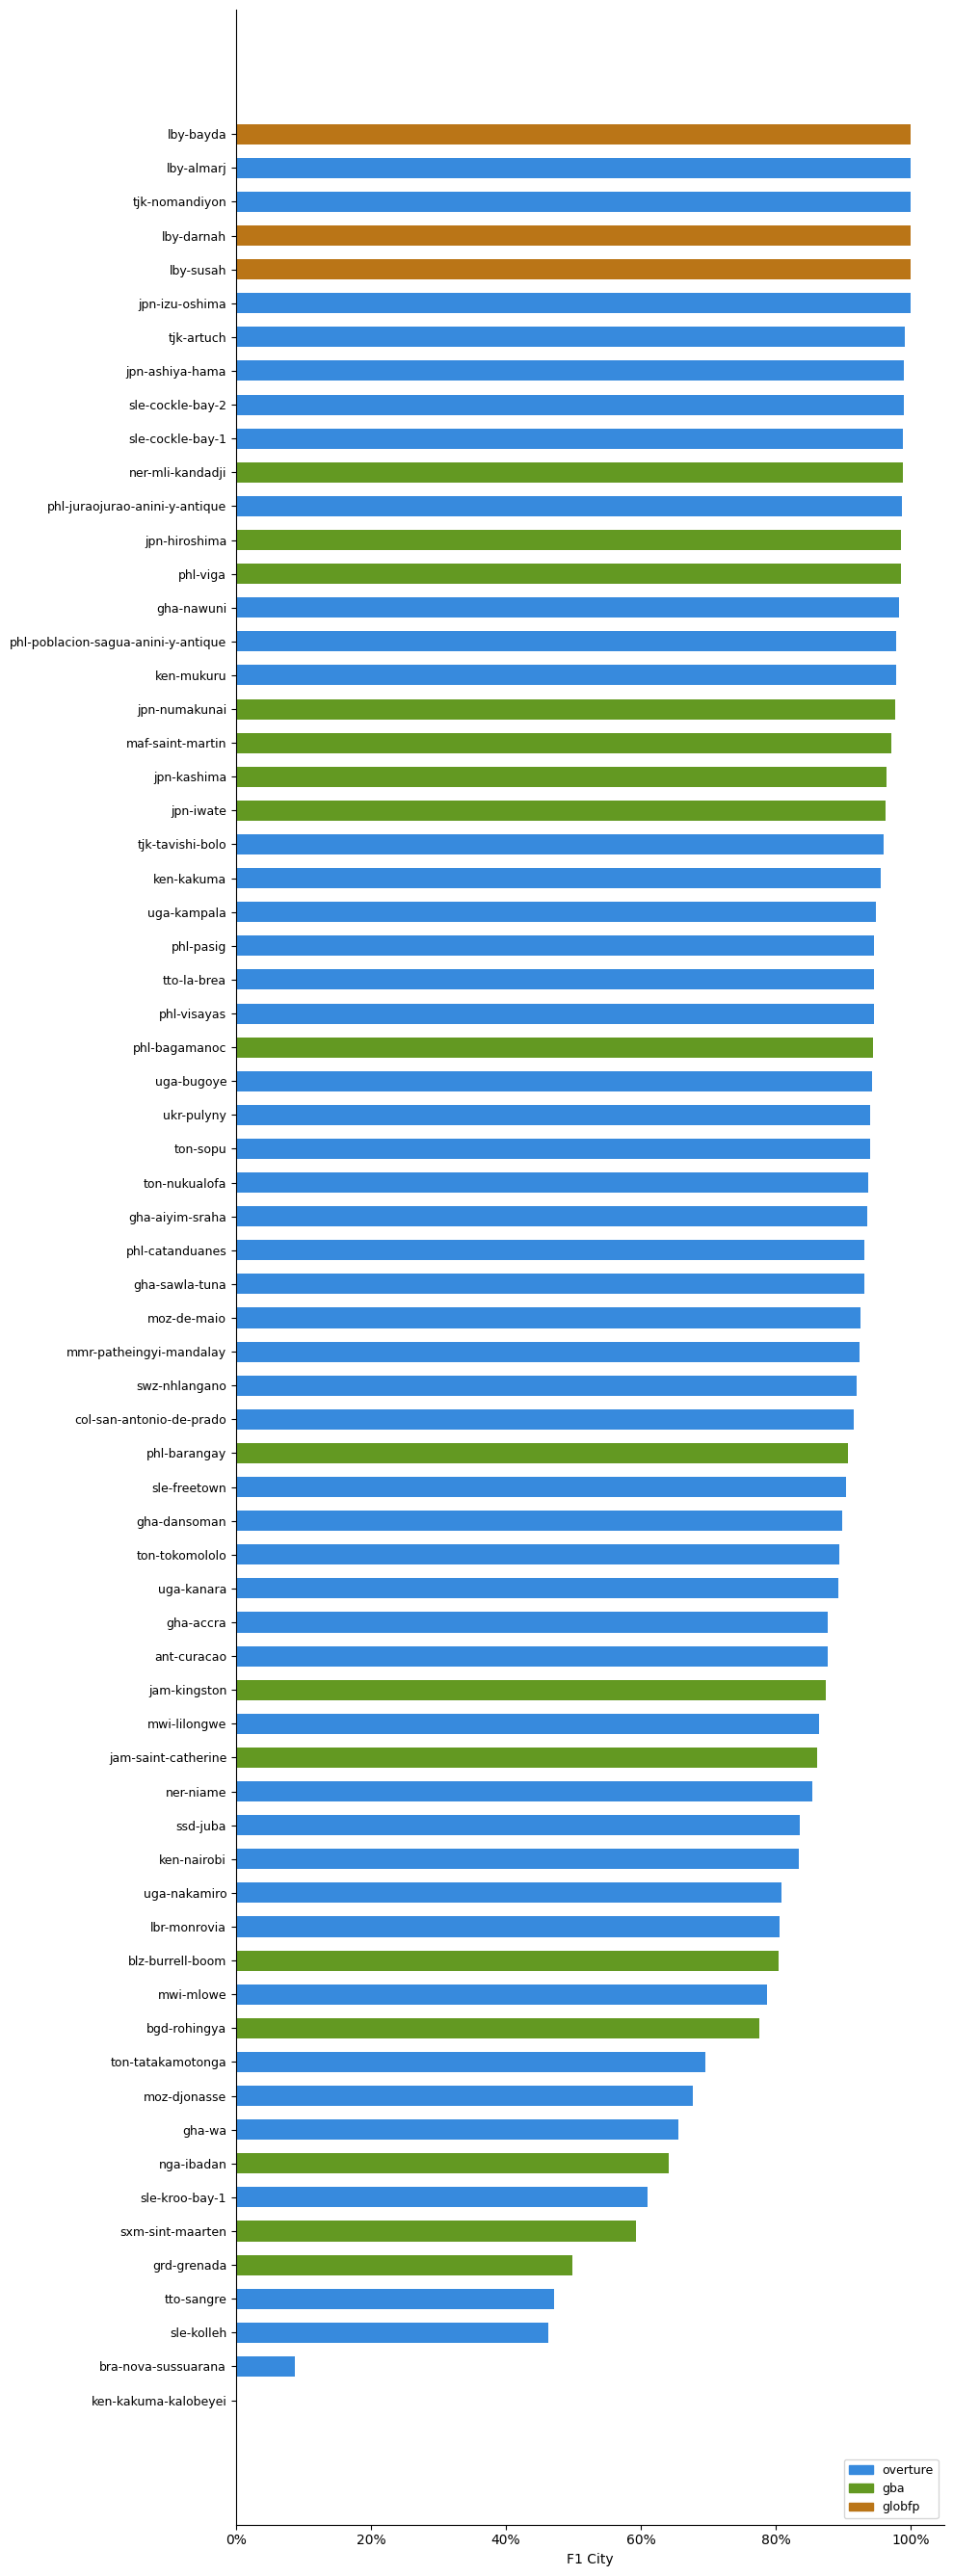

In [9]:
# visualize best dataset per city
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

metric = "f1_city"   # options: precision_city | recall_city | iou_mean_tp

df_plot = df_best.sort_values(metric, ascending=True)

palette = {"overture": "#378ADD", "gba": "#639922", "globfp": "#BA7517"}
colors = df_plot["dataset"].map(palette)

fig, ax = plt.subplots(figsize=(10, len(df_plot) * 0.38 + 1))
bars = ax.barh(df_plot["city"], df_plot[metric], color=colors, height=0.6)
ax.set_xlim(0, 1.05)
ax.set_xlabel(metric.replace("_", " ").title())
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.tick_params(axis="y", labelsize=9)
ax.spines[["top","right"]].set_visible(False)

legend = [mpatches.Patch(color=c, label=ds) for ds, c in palette.items()]
ax.legend(handles=legend, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

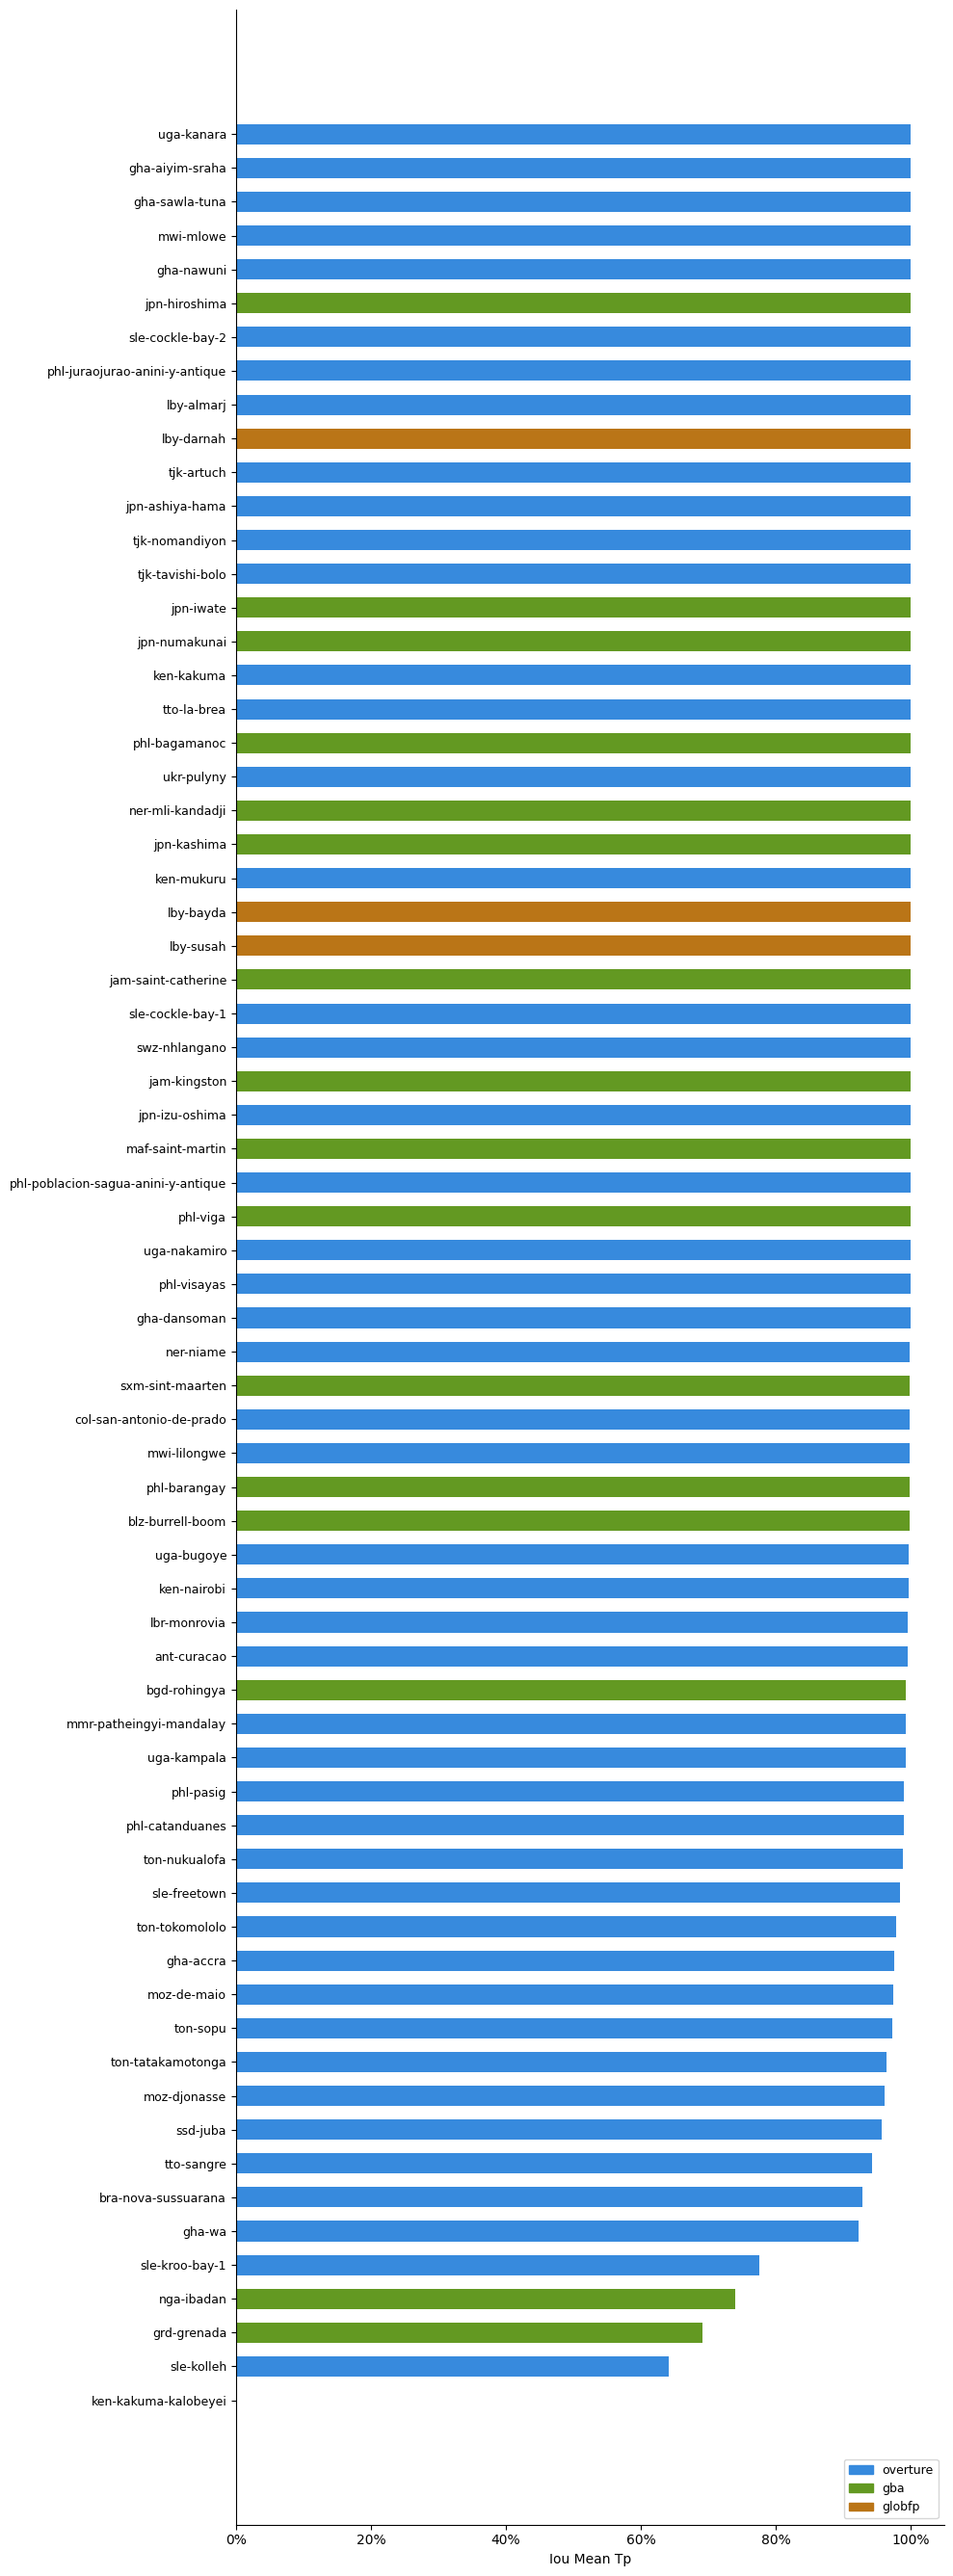

In [10]:
metric = "iou_mean_tp" 

df_plot = df_best.sort_values(metric, ascending=True)

palette = {"overture": "#378ADD", "gba": "#639922", "globfp": "#BA7517"}
colors = df_plot["dataset"].map(palette)

fig, ax = plt.subplots(figsize=(10, len(df_plot) * 0.38 + 1))
bars = ax.barh(df_plot["city"], df_plot[metric], color=colors, height=0.6)
ax.set_xlim(0, 1.05)
ax.set_xlabel(metric.replace("_", " ").title())
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.tick_params(axis="y", labelsize=9)
ax.spines[["top","right"]].set_visible(False)

legend = [mpatches.Patch(color=c, label=ds) for ds, c in palette.items()]
ax.legend(handles=legend, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()